In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'svg.fonttype': 'none',  # Export text as text not curves
    'font.size': 16, 
    "lines.linewidth": 2, 
    "axes.labelsize": 18,
    "axes.titlesize": 22
})

In [6]:
def construct_df():
    dbs = [
        "mcl1_vina_proto", "mcl1_mmpbsa_gb_proto"
    ]
    MOLS_PER_ITER = 600
    dfs = []
    for db in dbs:
        db_batch = f"{db}_batch.sqlite"
        db_sequential = f"{db}_shuffled.sqlite"

        data_batch, top_k_batch, source = load_data(f"results/{db_batch}", k_ratio=0.01)
        data_sequential, top_k, source = load_data(f"results/{db_sequential}", k_ratio=0.01)

        assert (top_k_batch == top_k).all().all()
        K = len(top_k)
        print(K)
        # data_batch["Surrogate"] = (data_batch["Surrogate"] + " (B)")
        data_batch["Iteration"] *= MOLS_PER_ITER
        data_sequential["Scenario"] = "Sequential"
        data_batch["Scenario"] = "Batched"
        data_batch["experiment_id"] = data_batch["experiment_id"] + data_sequential["experiment_id"].max()  # Start all from 0

        df = pd.concat([data_sequential, data_batch], ignore_index=True)
        df["Score"] = db
        dfs.append(df)

    full_df = pd.concat(dfs, ignore_index=True)
    full_df["Score"] = full_df["Score"].replace({"mcl1_vina_proto": "Docking", "mcl1_mmpbsa_gb_proto": "MMGBSA"})
    return full_df, K

In [7]:
df, size_top_k = construct_df()

593
593


Linear ['Linear']
Random Forest ['Random Forest']


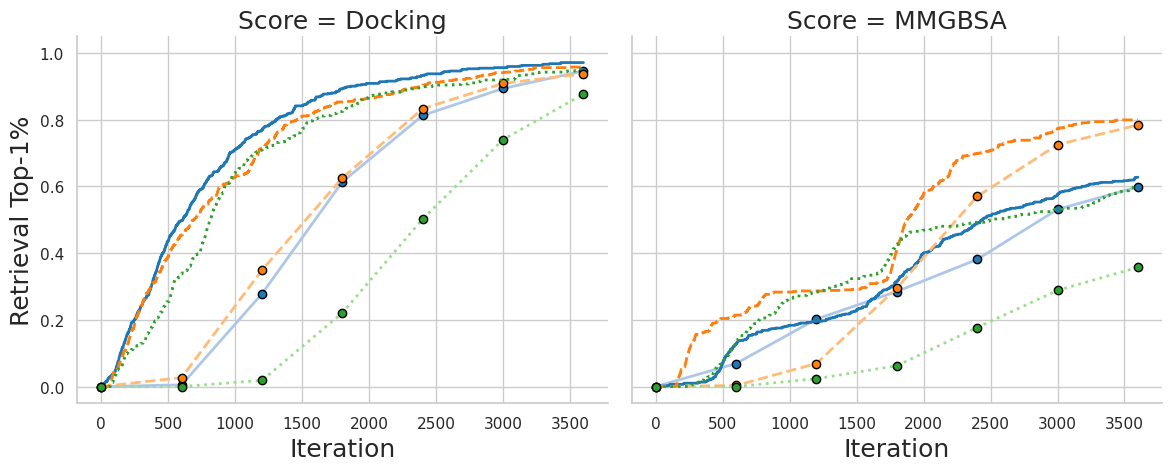

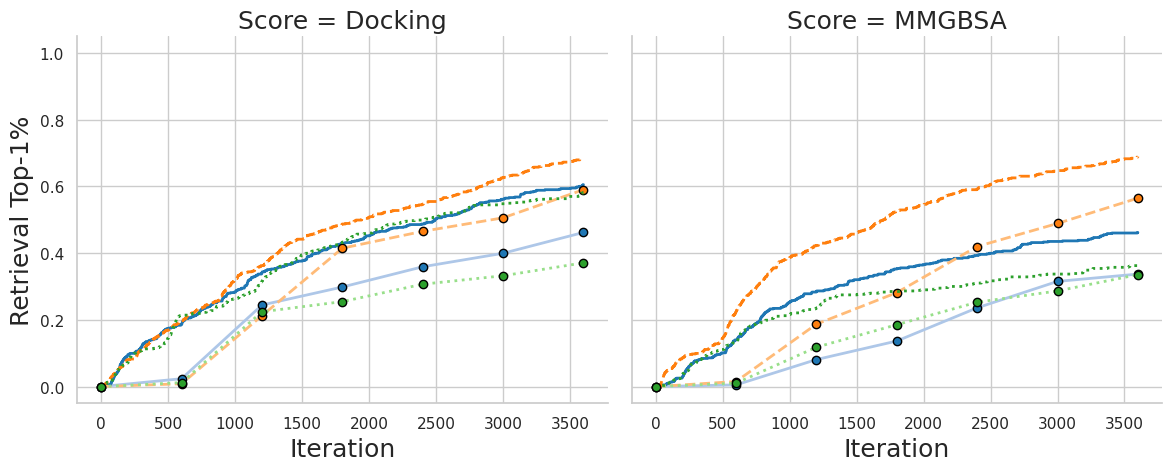

In [8]:
from utils import ProcessPlotter

for surrogat_model, model_df in df.groupby("Surrogate"):

    print(surrogat_model, model_df["Surrogate"].unique())

    p = ProcessPlotter(model_df, size_top_k)
    p.plot(col="Score", col_order=["Docking", "MMGBSA"])

    plt.savefig(f"figures/top_k_iter_both_{surrogat_model}.pdf", dpi=300, bbox_inches="tight")